#NBA Player Archetypes

In [1]:
## Cloning GitHub Repo
!git clone https://github.com/lindagu1/NBA_Archetypes.git
%cd NBA_Archetypes
!ls

Cloning into 'NBA_Archetypes'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 36 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 683.47 KiB | 8.44 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/NBA_Archetypes
data  output  README.md  scripts


In [2]:
%load_ext rpy2.ipython

## Notebook Overview

This notebook presents an exploratory analysis to identifying NBA player archetypes based on standardized performance statistics.

---
The analysis is structured as follows:


1.  **Introduction and Research Question**

    Motivation for identifying player archetypes and guiding research question.

2.  **Data Set and Cohort Definition**

    Description of the NBA dataset and inclusion criteria that ensured remaining players were active.

3.  **Feature Selection and Preprocessing**

    Rationale for feature selection, removal of metadata variables, and standardization of player statistics.

4.  **Methodology**

    Explanation of the k-means clustering approach and justification for the number of clusters.

5.  **Visualization via PCA**

    Two-dimensional projection of player clusters to aid interpretation.

6. **Cluster Profiles & Archetype Interpretation**

    Identification of defining statistical signatures for each cluster and assignment of archetype labels.

7. **Key Findings, Limitations, and Future Work**

    Summary of insights, methodological limitations, and potential extensions.

Note: Some figures and tables displayed in this notebook are loaded from precomputed outputs stored in the project repository to ensure fast execution and reproducibility.


## 1. Introduction and Research Question

As avid NBA fans, we often hear young players compared to established NBA legends—most recently, the rise of Victor Wembanyama and frequent comparisons to Rudy Gobert. While such comparisons are typically motivated by visible traits like height, wingspan, or defensive presence, they are often applied subjectively and can vary depending on context or analyst perspective. This motivates a data-driven approach to identifying player archetypes based on on-court performance rather than narrative labels.

The objective of this project is to determine whether we can uncover meaningful and interpretable NBA player archetypes using
standardized performance statistics. Rather than predicting an outcome or optimizing a supervised objective, this analysis focuses on grouping players with similar statistical profiles to reveal underlying role-based structure in the league.


---


**Research Question:**

Can NBA players be clustered into distinct archetypes based solely on their standardized statistical profiles, such that each cluster corresponds to a coherent style of play or functional role?

##2. Data Set and Cohort Definition

### 2.1 Data Set

The dataset used in this analysis, `nbastats.csv`, consists of player-level NBA performance statistics for a single regular season (2024-2025). Each observation corresponds to a player-season record and includes a combination of box score and advanced metrics intended to capture offensive and defensive impact as well as overall on-court involvement. These statistics serve as quantitative indicators of player roles and playing styles.

###2.2 Cohort Definition and Inclusion Criteria

To ensure that identified clusters reflect meaningful player roles, rather than noise from limited playtime, inclusion criteria were applied prior to analysis. Players were required to meet minimum thresholds for both games played (41) and average minutes per game (24). These filters exclude players with insufficient playing time whose statistics may not reliably represent a consistent role within their team's rotation.

Given by the distribution below, because our cohort was restricted to players averaging at least 24 minutes per game, the distribution reflects only players with sustainable on-court involvement.


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


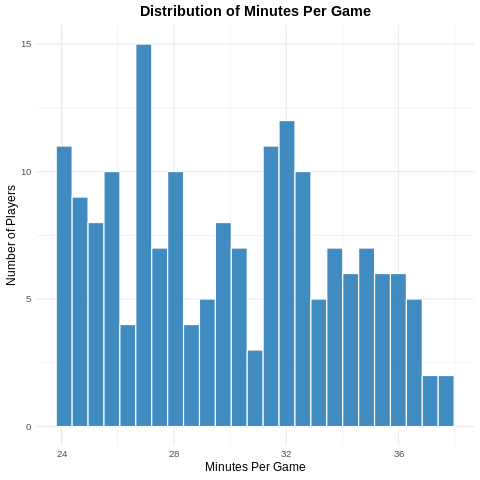

In [3]:
%%R
library(tidyverse)

player_index <- readr::read_csv(
  "output/tables/player_index.csv",
  show_col_types = FALSE)

player_index <- player_index %>%
mutate(minutes_per_game = MP / G)

ggplot(player_index, aes(minutes_per_game)) +
geom_histogram(
    bins = 25,
    fill = "#2C7FB8",
    color = "white",
    alpha = 0.9
  ) +
labs(
    title = "Distribution of Minutes Per Game",
    x = "Minutes Per Game",
    y = "Number of Players") +
theme_minimal(base_size = 12) +
theme(plot.title = element_text(face = "bold", hjust = 0.5))


Additionally, players who appeared multiple times in the dataset due to mid-season trades were deduplicated to ensure each player contributed exactly one record to the analysis. In such cases, the player's record corresponding to their highest total minutes played was retained, as it best reflects their primary role during the season.

## 3. Feature Selection and Preprocessing

###3.1 Separation of Metadata and Model Inputs




Prior to clustering, player attributes were divided into two categories: metadata variables and model input features. Metadata variables include player name, team, position, age, games played, and minutes played. These variables serve an identification or contextual purpose but do not directly describe playing style. Because distance-based clustering relies on quantitative similarity, including these identifiers would add noise without contributing meaningful information about player roles.




Accordingly, metadata variables were stored separately and excluded from the feature matrix used for clustering. This ensures that similarity between players is determined solely by on-court performance statistics, while metadata remains available for interpretation and labeling of results later on.

###3.2 Feature Selection

Feature selection was guided by the objective of capturing stylistic differences in how players contribute on the court. After cohort filtering and deduplication, only numeric performance variables were considered as candidates for clustering, while identifying metadata that we previously filtered were explicitly excluded.

Several categories of numeric variables were removed prior to clustering. Raw counting totals such as games played, minutes played, and total points were excluded because they primarily reflect opportunity rather than role. Percentage statistics such as field goal percentage and free throw percentage were also removed as it is highly sensitive to sample size. Additionally, variables that were redundant or closely tied to playing time were excluding to reduce collinearity and to prevent clustering from being dominated by variables with large numeric ranges.

The remaning features consist of standardized rate-based and activity-based statistics that capture offensive usage, playmaking tendancies, rebounding involvement, and defensive activity. This feature set emphasizes how players impact the game, rather than how much they play, aligning the clustering objective with the identification of role-based player archetypes.

###3.3 Feature Standardization




Prior to clustering, all selected performance features were standardized using z-score normalization. This transformation ensures that all variables are expressed on a common scale with a mean of zero and unit variance.




Standardization is essential for distance-based clustering methods such as k-means, which rely on Euclidean distance to measure similarity between players. Without scaling, features with larger numerical ranges, such as count-based activity metrics, would disproportionately influence cluster assignments, regardless of their relevance to player role.




Under this representation, positive standardized values indicate above-average performance relative to the cohort, while negative values indicate below-average performance. This approach stabilizes the clustering process and makes cluster profiles easier to interpret, since cluster-level feature means can be compared directly.

##4. Methodology

###4.1 Unsupervised Learning Framework

Because player archetypes are not labeled in available NBA data, this analysis adopts an unsupervised learning framework. Rather than predicting a target variable, the objective is to uncover latent structure in the feature space by grouping players with similar standardized statistical profiles.

###4.2 K-Means Clustering




Player archetypes were identified using k-means clustering. K-means was selected for its simplicity, computational efficiency, and interpretability. When applied to standardized features, cluster centroids can be directly interpreted as archetypal profiles, with centroid values indicating relative strengths and weaknesses across performance dimensions.

###4.3 Selection of Number of Clusters




The number of clusters \(k\) was not assumed based on prior knowledge and was instead informed by multiple commonly used diagnostic heuristics, including the elbow method, silhouette score, and gap statistic. These metrics provide complementary information about inner cluster compactness, between-cluster separation, and structure relative to random reference data.

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

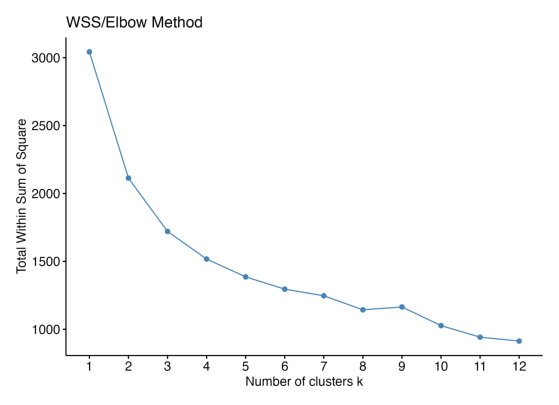

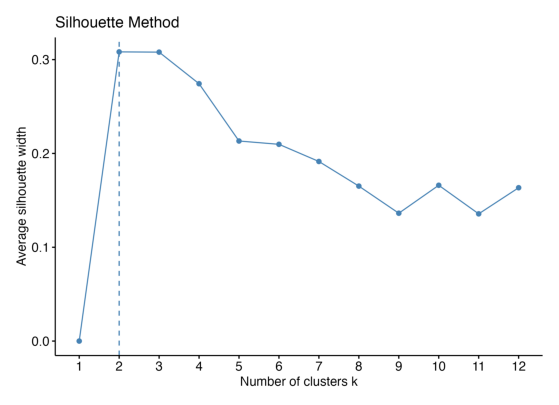

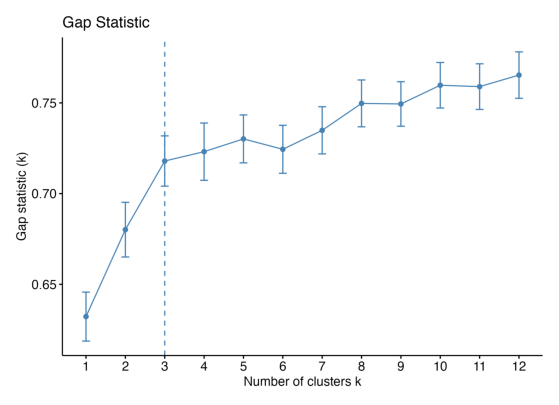

In [13]:
paths = [
    "output/figure/k_elbow_wss.png",
    "output/figure/k_silhouette.png",
    "output/figure/k_gap_statistic.png",
]

for p in paths:
    img = Image.open(p)
    plt.figure(figsize=(8,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


In this analysis, the elbow method suggested a value of approximately \(k = 7\), the silhouette score favored a smaller number of clusters, and the gap statistic indicated a minimum viable cluster count. As these diagnostics did not converge on a single optimal value, the final choice of \(k\) was guided by a balance between quantitative signals and qualitative interpretability. A value of \(k = 7\) was selected to preserve meaningful distinctions between player roles without splitting the feature space into an excessive number of small unstable clusters.

### 4.4 Final Model Fitting and Reproducibility




After selecting \(k = 7\), the final k-means model was fit to the standardized feature matrix using multiple random initializations (nstart = 50\) and a fixed random seed to reduce sensitivity to initialization and ensure reproducibility. Player-to-cluster assignments and the fitted clustering model were saved, enabling downstream visualization and interpretation without re-estimating the clustering solution.

##5. Results

###5.1 Cluster Assignment Summary




Using \(k=7\), all players in the cohort were assigned to one of seven clusters based on similarity in standardized performance features. Cluster sizes were moderately balanced, indicating that the clustering solution did not collapse into a small number of dominant groups or isolate an excessive number of players into one-player clusters. This distribution suggests that the selected feature space supports multiple distinct player archetypes with sufficient representation for analysis.





---






The distribution of players across clusters is summarized below.

In [14]:
%%R
library(tidyverse)

clusters <- readr::read_csv("output/tables/player_clusters.csv", show_col_types = FALSE)

clusters %>%
  count(Cluster, name = "Number of Players") %>%
  arrange(Cluster)

# A tibble: 7 × 2
  Cluster `Number of Players`
    <dbl>               <int>
1       1                  22
2       2                  30
3       3                  12
4       4                  67
5       5                   2
6       6                  28
7       7                  19


###5.2 Visualization of Player Clusters via PCA




To visualize the clustering structure, players were projected onto the first two principal components of the standardized feature matrix. This projection is used solely to visualize and does not influence the clustering procedure.

The resulting two-dimensional representation reveals partially separated groups of players corresponding to the seven clusters, with some overlap between clusters reflecting the continuous nature of player roles. Representative players (defined as those closest to their respective cluster centroids) are highlighted to provide intuitive anchors for interpreting each cluster's position within the feature space.


---
Below is the resulting clustering structure using a two-dimensional PCA projection of the standardized feature space, which includes one representative player from each cluster, selected as the player closest to the corresponding cluster centroid.

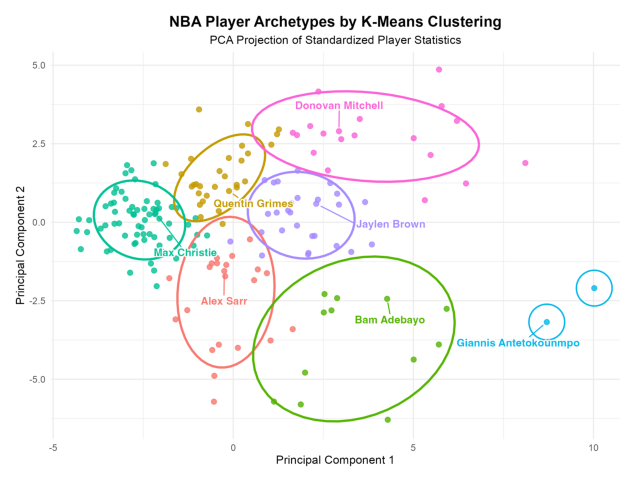

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("output/figure/nba_player_clusters.png")

plt.figure(figsize=(9, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

###5.3 Summary of Results

Overall, the clustering results indicate that NBA players can be grouped into a moderate number of statistically distinct clusters based on standardized performance statistics. These clusters exhibit sufficient separation to support interpretation, while still reflecting the nature of on-court roles.

The following section examines the defining characteristics of each cluster and connects these statistical patterns to interpretable player archetypes.


##6. Cluster Profiles and Archetype Interpretation

###6.1 Cluster Feature Profiles

For each cluster, features were ranked by their mean standardized values to identify the statistics that most strongly distinguish that group. Differences across clusters emerge along multiple dimensions, including offensive usage, playmaking involvement, rebounding activity, and defensive contribution. Rather than being defined by a single statistic, each cluster reflects a distinct combination of strengths and weaknesses across several performance dimensions.

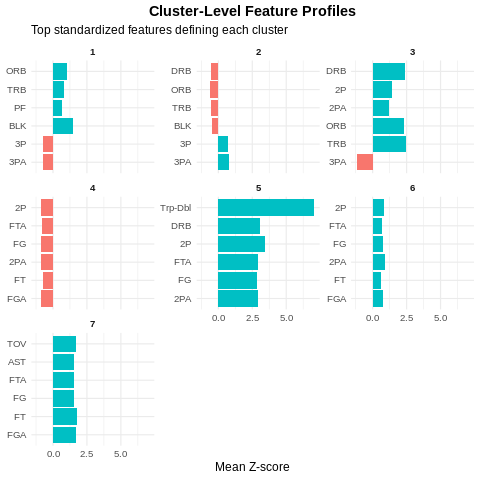

In [18]:
%%R
library(tidyverse)

# Load artifacts
X <- readRDS("output/tables/nba_features_scaled.rds")
clusters <- readr::read_csv("output/tables/player_clusters.csv", show_col_types = FALSE)

# Join cluster labels
X_df <- as_tibble(X, rownames = "Player") %>%
  left_join(clusters, by = "Player")

# Compute cluster-level means
cluster_profiles <- X_df %>%
  pivot_longer(
    cols = -c(Player, Cluster),
    names_to = "Feature",
    values_to = "Z"
  ) %>%
  group_by(Cluster, Feature) %>%
  summarise(mean_z = mean(Z), .groups = "drop")

# Select most defining features per cluster
top_features <- cluster_profiles %>%
  group_by(Cluster) %>%
  slice_max(order_by = abs(mean_z), n = 6) %>%
  ungroup()

# Plot
ggplot(top_features,
       aes(x = reorder(Feature, mean_z),
           y = mean_z,
           fill = mean_z > 0)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  facet_wrap(~ Cluster, scales = "free_y") +
  labs(
    title = "Cluster-Level Feature Profiles",
    subtitle = "Top standardized features defining each cluster",
    x = NULL,
    y = "Mean Z-score"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    strip.text = element_text(face = "bold", hjust = 0.5)
  )

### 6.2 Archetype Interpretation and Representative Players

Based on these feature profiles, descriptive archetype labels were assigned to each cluster to aid interpretation. These labels are intended as heuristic summaries of dominant statistical tendencies rather than rigid classifications, acknowledging that player roles exist along a continuum.

To ground each archetype in an intuitive basketball context, one representative player from each cluster was identified. Representative players were defined as those closest to their respective cluster centroids in the standardized feature space, serving as concrete reference points for the broader archetypal profile captured by each cluster.

### 6.3 Final Archetype Labels

Based on the statistical feature profiles and qualitative interpretation
discussed above, each cluster was assigned a descriptive archetype label. These
labels serve as concise summaries of the dominant performance patterns captured
by each cluster and are intended to aid interpretation rather than impose rigid
categorization.

| Cluster | Archetype Label |
|--------:|----------------|
| 1 | Defensive Rim Protectors |
| 2 | Perimeter Shooters and Secondary Guards |
| 3 | Interior Bigs |
| 4 | Low-Usage Role Players |
| 5 | Superstar Offensive Hubs |
| 6 | Versatile Two-Way Forwards |
| 7 | Primary Shot Creators |


### 6.4 Archetype Interpretation with Player Examples




The archetype labels assigned above are reflected in the composition of each cluster, with player groupings aligning closely with intuitive basketball roles. Selected examples from each cluster illustrate how the statistical profiles map to real on-court responsibilities.




**Cluster 1—Defensive Rim Protectors.**  

This cluster is dominated by players whose value comes primarily from the interior defense, rim protection, and rebounding rather than offensive creation. Players such as Victor Wembanyama, Rudy Gobert, and Myles Turner exemplify this archetype, anchoring defenses through shot-blocking and paint presence.




**Cluster 2—Perimeter Shooters and Secondary Guards.**

Players in this cluster provide spacing, off-ball shooting, and secondary ball-handling without carrying primary offensive responsibility. Examples include Klay Thompson, CJ McCollum, and Derrick White, who contribute scoring and playmaking within structured offensive systems.




**Cluster 3—Interior Bigs.**

This archetype captures high-usage frontcourt players who combine interior scoring, rebounding, and physical presence. Players such as Anthony Davis, Domantas Sabonis and Bam Adebayo reflect this role, contributing on both ends of the floor with an emphasis on interior impact.




**Cluster 4 — Low-Usage Role Players.**

This cluster includes players whose contributions are complementary rather than ball-dominant, often excelling in defense, spacing, or connective play. Examples such as Kentavious Caldwell-Pope, Royce O'Neale, and Josh Green highlight the importance of low-usage efficiency and situational impact.

**Cluster 5 — Superstar Offensive Hubs.**

This small but distinct cluster is composed of players who serve as the primary engine of their team’s offense, combining scoring, playmaking, and usage at elite levels. Nikola Jokić and Giannis Antetokounmpo exemplify this archetype, with offenses structured around their multifaceted skill sets.

**Cluster 6 — Versatile Two-Way Forwards.**

Players in this group contribute across scoring, defense, and playmaking without being limited to a single role. Examples such as Jimmy Butler, Jayson Tatum, and Scottie Barnes demonstrate the flexibility and two-way impact that define this archetype.




**Cluster 7 — Primary Shot Creators.**

This cluster consists of players responsible for generating offense at high volume, often through isolation scoring, pick-and-roll creation, and perimeter shot-making. Players such as Stephen Curry, Luka Dončić, and Shai Gilgeous-Alexander exemplify this role as focal points of offensive creation.

##7. Key Findings, Limitations, and Future Work

###7.1 Key Findings




This analysis demonstrates that NBA players can be meaningfully grouped into distinct and interpretable archetypes using unsupervised learning applied to standardized performance statistics. The resulting clusters align closely with intuitive basketball roles, including Defensive Rim Protectors, Primary Shot Creators, and Superstar Offensive Hubs, despite the model having no access to positional labels or subjective evaluations.




Importantly, these archetypes emerge from combinations of statistical features rather than single defining metrics. For example, Primary Shot Creators and Superstar Offensive Hubs are differentiated not solely by scoring volume, but by the balance between usage, playmaking, and secondary contributions. Similarly, the distinction between Defensive Rim Protectors and Interior Bigs highlights how defensive activity and offensive involvement jointly shape player roles. These findings suggest that standardized performance profiles capture meaningful structure underlying how players contribute on the court.

### 7.2 Limitations




Several limitations should be considered when interpreting these results. First, the clustering outcomes depend on feature selection and preprocessing choices, and alternative representations of player performance may yield different archetype structures. While care was taken to emphasize role-defining statistics, the definition of “playing style” remains inherently subjective.




Second, the use of k-means clustering imposes assumptions about cluster shape and separation that may not fully reflect the complexity of NBA player roles. Observed overlap between archetypes (particularly among Versatile Two-Way Forwards, Perimeter Shooters and Secondary Guards, and Primary Shot Creators) reflects both methodological limitations and the fluid nature of modern basketball roles.




Finally, this analysis is based on data from a single season and does not account for contextual factors such as team systems, coaching strategies, or player development over time. As a result, archetype assignments should be interpreted as season-specific characterizations rather than fixed player identities.

### 7.3 Future Work




Future extensions of this project could examine the stability and evolution of player archetypes across multiple seasons, enabling analysis of role transitions as players develop or change team contexts. Tracking how players move between archetypes over time could provide insights into career trajectories and skill development.




Additional improvements could include incorporating lineup-level context, spatial tracking data, or alternative clustering methods such as hierarchical or density-based approaches. These extensions may capture more nuanced relationships between players and further refine the distinction between closely related archetypes.




Overall, this project illustrates how unsupervised learning can transform high-dimensional sports data into structured, interpretable narratives, bridging quantitative analysis with intuitive understanding of player roles.